[scikit-image-Radon_transform](https://scikit-image.org/docs/0.25.x/auto_examples/transform/plot_radon_transform.html)

## The forward transform
As a rule of thumb, the number of projections should be about the same as the number of pixels there are across the object.

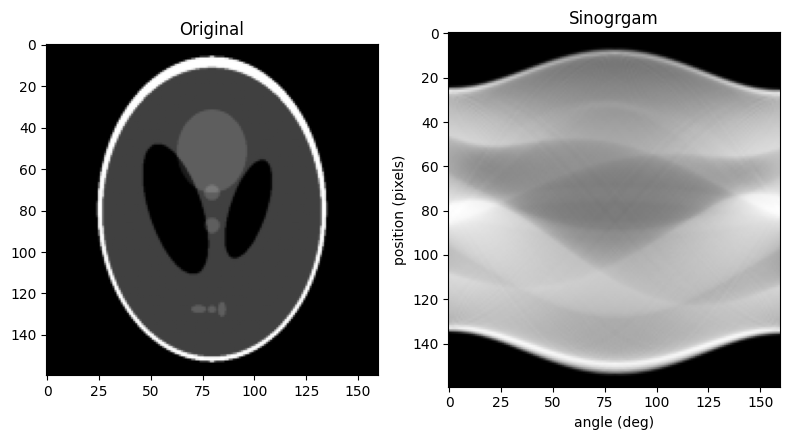

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 

from skimage.data import shepp_logan_phantom
from skimage.transform import radon, rescale
 
image = shepp_logan_phantom() # shape (400, 400)
image = rescale(image, scale=0.4, mode='reflect', channel_axis=None)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4.5))

ax1.set_title("Original")
ax1.imshow(image, cmap=plt.cm.Greys_r)

theta = np.linspace(0.0, 180.0, num=max(image.shape), endpoint=False)
sinogram = radon(image, theta=theta)

ax2.set_title("Sinogrgam")
ax2.set_xlabel("angle (deg)")
ax2.set_ylabel("position (pixels)")
ax2.imshow(sinogram, cmap=plt.cm.Greys_r)

fig.tight_layout()
plt.show()


## FBP

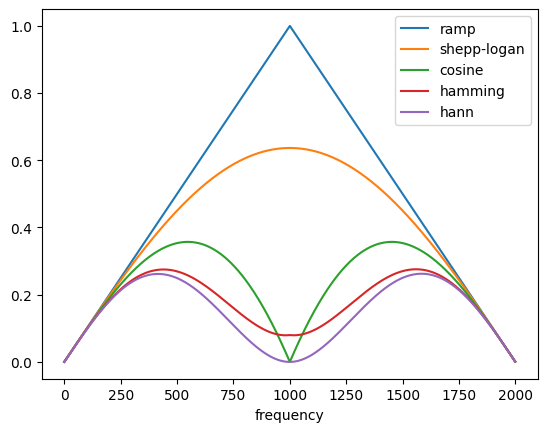

In [12]:
import matplotlib.pyplot as plt
from skimage.transform.radon_transform import _get_fourier_filter

filters = ['ramp', 'shepp-logan', 'cosine', 'hamming', 'hann']

for ix, f, in enumerate(filters):
    response = _get_fourier_filter(2000, f)
    plt.plot(response, label=f)

plt.xlabel('frequency')
plt.legend()
plt.show()

FBP rms reconstruction error: 0.0283


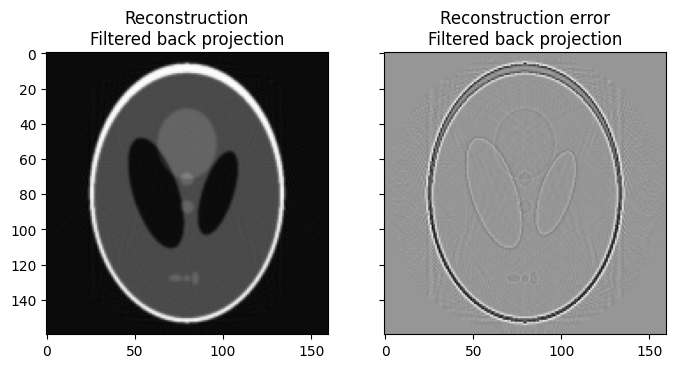

In [14]:
from skimage.transform import iradon

reconstruction_fbp = iradon(sinogram, theta=theta, filter_name='ramp')
error = reconstruction_fbp - image
print(f'FBP rms reconstruction error: {np.sqrt(np.mean(error**2)):.3g}')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8, 4.5), sharex=True, sharey=True)
ax1.set_title("Reconstruction\nFiltered back projection")
ax1.imshow(reconstruction_fbp, cmap=plt.cm.Greys_r)
ax2.set_title("Reconstruction error\nFiltered back projection")
imkwargs = dict(vmin=-0.2, vmax=0.2)
ax2.imshow(reconstruction_fbp - image, cmap=plt.cm.Greys_r, **imkwargs)
plt.show()

## Simple 2D ML test

In [1]:
from simple_2D_train import load_run
from mcgpu_backend import show_3dimage, show_2dimage

model, cfg, history, arrays = load_run("runs/run0/ml_unet_poisson_nll")

scatter_pred = arrays["scatter_pred"]           # predicted scatter counts
scatter_true = arrays["scatter_true"]
total        = arrays["total"]
val_idx      = arrays["val_indices"]            # which slices were held out

# Estimated true coincidences after scatter correction:
trues_estimated = total - scatter_pred
trues = total - scatter_true

print("Scatter factor = ", scatter_true.sum()/total.sum())

from mcgpu_backend.utilities import fbp_stack, show_2dimage, show_3dimage

img_total = fbp_stack(total)
img_true  = fbp_stack(trues)             # total - scatter_true
img_est   = fbp_stack(trues_estimated)   # total - scatter_pred

show_2dimage(img_total[79], "FBP total (z=79)", "fbp_total.png")
show_2dimage(img_true[79],  "FBP true  (z=79)", "fbp_true.png")
show_2dimage(img_est[79],   "FBP est   (z=79)", "fbp_est.png")



Scatter factor =  0.1613948
figure saved as fbp_total.png
figure saved as fbp_true.png
figure saved as fbp_est.png
